# A Linear-Response Model of Galaxy-Group Scaling Relations

### From a learned baryon-painting emulator to a *differentiable, invertible* map between sub-grid feedback physics and observable group scaling relations

---

Everything we have done in this repository so far has been **validation**: showing that the
flow-matching model paints baryons onto dark-matter-only fields in a way that reproduces the
CAMELS IllustrisTNG hydro statistics. The population-Jacobian bar charts in
`analysis_cv_derivatives_scatter.ipynb` are the hinge point where validation turns into
*modelling*. They quantify

$$ J^{\rm pop}_{kj} \;=\; \frac{\partial S_k}{\partial \tilde\theta_j} $$

— how each **scaling-relation statistic** $S_k$ (a slope $\alpha$, intercept $\beta$, or
scatter $\sigma$) responds to each **CAMELS sub-grid parameter** $\tilde\theta_j$ (cosmology +
stellar/AGN feedback). This notebook does three things:

1. **Makes the Jacobian concrete** — builds up from the raw scaling relation, to *watching it move*
   when a feedback knob is turned, to the bar chart, so the meaning of every bar is unambiguous.
2. **Identifies the highest-impact use** — the Jacobian is the *linearisation of the otherwise
   intractable inverse map* from feedback physics to observables. That is exactly what the galaxy-groups
   community needs: groups ($10^{13}$–$10^{14.5}\,M_\odot$) are where AGN feedback governs the baryon
   budget, and surveys (eROSITA, weak lensing, kSZ) measure precisely these relations.
3. **Builds a rigorous, useful model** — a **tangent-space response model**
   $\,S(\theta)\approx S_0 + J\,\Delta\tilde\theta\,$, *validated against held-out simulations*, and turned
   into a closed-form **Bayesian linear inversion / Fisher forecast** that recovers feedback parameters
   from measured group scaling relations.

## 0 · Setup

We load the cached population Jacobian (`Jpop`, shape $(35,)$ per statistic, computed by
central finite difference of the model around the CAMELS fiducial point), and define helpers to
compute the five scaling relations from any simulation's model-generated halos.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.axisbelow': True})

ROOT      = Path('/mnt/home/mlee1/vdm_bind2')
sys.path.insert(0, str(ROOT))
CACHE_DIR = ROOT / 'analysis_physics_cache'
FM_RUN_DIR  = Path('/mnt/home/mlee1/ceph/fm_runs/fm_two_head')
CV_FD_CACHE = CACHE_DIR / 'proj6_cv_fd_scatter_fm_two_head.npz'
TESTSUITE   = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SUB, GEN    = 'snap_090/mass_threshold_1p000e13', 'fm_two_head'
N_PARAMS    = 35

from data import NormStats
from fd_jacobian_cv import observables_from_phys, _fit_relation, r200c_mpc_h, MPC_PER_PIX

norm_stats = NormStats.load(FM_RUN_DIR / 'norm_stats.npz')
LOG_FLAG   = norm_stats.param_log_flag.astype(int)
P_MIN, P_MAX = norm_stats.param_min, norm_stats.param_max
P_RANGE    = P_MAX - P_MIN

# CAMELS parameter labels & physics grouping (cosmo / SN / AGN / other)
PRETTY = {0:r'$\Omega_m$',1:r'$\sigma_8$',2:r'$A_{\rm SN1}$',3:r'$A_{\rm AGN1}$',4:r'$A_{\rm SN2}$',
          5:r'$A_{\rm AGN2}$',6:r'$\Omega_b$',7:r'$h$',8:r'$n_s$',9:r'$w_0$',10:r'$w_a$',11:r'$M_\nu$',
          12:r'$\alpha_{\rm SF}$',13:r'$\beta_{\rm SF}$',14:r'$\rho_{\rm wind}$',15:r'$M_{\rm SNII}$',
          16:r'$\eta_w$',17:r'$E_{\rm SN}$',18:r'$\epsilon_r$',19:r'$M_{\rm seed}$',20:r'$\alpha_{\rm acc}$',
          21:r'$\beta_{\rm acc}$',22:r'$M_{\rm fof}$',23:r'$V_{\rm Bh}$',24:r'$\alpha_{w,{\rm SN}}$',
          25:r'$\tau_{\rm BH}$',26:r'$p_{\rm wind}$',27:r'$v_{\rm kick}$',28:r'$\alpha_{w,Z}$',
          29:r'$R_{\rm trunc}$',30:r'$\beta_{\rm UV}$',31:r'$\alpha_{\rm UV}$',32:r'$\beta_{\rm HeII}$',
          33:r'$T_{\rm reion}$',34:r'$z_{\rm reion}$'}
PARAM_GROUP = {0:'cosmo',1:'cosmo',2:'SN',3:'AGN',4:'SN',5:'AGN',6:'cosmo',7:'cosmo',8:'cosmo',
               9:'cosmo',10:'cosmo',11:'cosmo',12:'SN',13:'SN',14:'SN',15:'SN',16:'SN',17:'SN',
               18:'AGN',19:'AGN',20:'AGN',21:'AGN',22:'AGN',23:'AGN',24:'SN',25:'AGN',26:'SN',
               27:'SN',28:'SN',29:'other',30:'other',31:'other',32:'other',33:'other',34:'other'}
GROUP_COLORS = {'cosmo':'#1E88E5','SN':'#FB8C00','AGN':'#E53935','other':'#757575'}

print('NormStats loaded.  log-flagged params:', np.where(LOG_FLAG==1)[0].tolist())

NormStats loaded.  log-flagged params: [2, 3, 4, 5, 9, 10, 13, 15, 17, 18, 21, 22, 23, 24, 25, 26, 28, 30, 34]


In [2]:
# ── Scaling-relation registry ────────────────────────────────────────────────
# Each relation:  log10(y) = alpha * log10(x) + beta,  with Gaussian scatter sigma.
RELATIONS = {
    'MgMs':  dict(latex=r'$M_{\rm gas}\!-\!M_\star$',   x='M_star', y='M_gas',  group=False),
    'MdMs':  dict(latex=r'$M_{\rm DM}\!-\!M_\star$',    x='M_star', y='M_dm',   group=False),
    'SHMR':  dict(latex=r'$M_\star\!-\!M_{200c}$',      x='M200c',  y='M_star', group=True),
    'GasFr': dict(latex=r'$M_{\rm gas}\!-\!M_{200c}$',  x='M200c',  y='M_gas',  group=True),
    'BarFr': dict(latex=r'$M_{\rm bar}\!-\!M_{200c}$',  x='M200c',  y='M_bar',  group=True),
}
STATS      = ['alpha', 'beta', 'sigma']
STAT_LATEX = {'alpha':r'slope $\alpha$', 'beta':r'intercept $\beta$', 'sigma':r'scatter $\sigma$'}
POP_KEYS   = [f'{s}_{r}' for r in RELATIONS for s in STATS]                 # 15 statistics
GROUP_RELS = [r for r in RELATIONS if RELATIONS[r]['group']]               # M200c-anchored
GROUP_KEYS = [f'{s}_{r}' for r in GROUP_RELS for s in STATS]               # 9 group statistics

# ── Load cached population Jacobian  Jpop[stat] -> (35,) ─────────────────────
z    = np.load(CV_FD_CACHE, allow_pickle=True)
Jpop = {k[5:]: z[k].astype(float) for k in z.files if k.startswith('Jpop_')}
meta = z['meta'].item()
print(f"Loaded Jpop for {len(Jpop)} statistics.  FD step eps = {meta['eps']}  "
      f"(normalised-parameter units),  n_halos = {meta['n_use']}")
print('Group-relevant statistics:', GROUP_KEYS)

Loaded Jpop for 15 statistics.  FD step eps = 0.001  (normalised-parameter units),  n_halos = 1154
Group-relevant statistics: ['alpha_SHMR', 'beta_SHMR', 'sigma_SHMR', 'alpha_GasFr', 'beta_GasFr', 'sigma_GasFr', 'alpha_BarFr', 'beta_BarFr', 'sigma_BarFr']


In [3]:
# ── Parameter normalisation (matches fd_jacobian_cv.normalize_params_fid) ────
def to_norm(p_raw):
    p = np.asarray(p_raw, float)
    q = np.where(LOG_FLAG == 1, np.log10(np.maximum(p, 1e-30)), p)
    return (q - P_MIN) / (P_RANGE + 1e-8)

# ── Compute per-halo masses from a sim's MODEL-GENERATED maps ────────────────
def halo_masses_from_sim(suite, sim):
    d   = TESTSUITE / suite / sim / SUB
    cat = np.load(d / 'halo_catalog.npz', allow_pickle=True)
    gen = np.load(d / GEN / 'generated_halos.npz')['generated']      # (N,3,128,128) physical Msun/h
    M200      = cat['masses'].astype(float)
    radii_pix = cat['radii'].astype(float) / 1000.0 / MPC_PER_PIX    # kpc/h -> pixels (== FD radii_pix)
    out = {k: np.full(len(gen), np.nan) for k in ['M_dm', 'M_gas', 'M_star', 'M_bar']}
    for i in range(len(gen)):
        o = observables_from_phys(gen[i].astype(np.float64), radii_pix[i], np.nan)
        for k in out:
            out[k][i] = o[k]
    out['M200c'] = M200
    return out, cat['params'][0].astype(float)

def fit_all_relations(masses):
    S = {}
    for r, info in RELATIONS.items():
        a, b, s = _fit_relation(masses[info['x']], masses[info['y']])
        S[f'alpha_{r}'], S[f'beta_{r}'], S[f'sigma_{r}'] = a, b, s
    return S

# ── Fiducial operating point  S_0 = S(theta_0)  from the canonical fiducial 1P_p1_0 ──
# (p14 = rho_wind carries the known CAMELS run/file mismatch -> override to 0, matching training.)
fid_masses, fid_praw = halo_masses_from_sim('1P', '1P_p1_0')
fid_praw = fid_praw.copy(); fid_praw[14] = 0.0
theta0   = to_norm(fid_praw)
S0       = fit_all_relations(fid_masses)

print(f"Fiducial halos: {len(fid_masses['M200c'])}   "
      f"log10 M200c in [{np.log10(fid_masses['M200c'].min()):.2f}, "
      f"{np.log10(fid_masses['M200c'].max()):.2f}]")
for k in GROUP_KEYS:
    print(f"  S0[{k:12s}] = {S0[k]:+.4f}")

Fiducial halos: 49   log10 M200c in [13.02, 14.14]
  S0[alpha_SHMR  ] = +0.9893
  S0[beta_SHMR   ] = -1.7107
  S0[sigma_SHMR  ] = +0.0867
  S0[alpha_GasFr ] = +1.2169
  S0[beta_GasFr  ] = -3.7076
  S0[sigma_GasFr ] = +0.0912
  S0[alpha_BarFr ] = +1.1971
  S0[beta_BarFr  ] = -3.4042
  S0[sigma_BarFr ] = +0.0850


## 1 · What the population Jacobian actually shows

A **scaling relation** is the headline statistic for galaxy groups: pick a halo property on each
axis, fit a power law in log-space, and report three numbers —

$$ \log_{10} y \;=\; \underbrace{\alpha}_{\text{slope}}\,\log_{10} x \;+\; \underbrace{\beta}_{\text{intercept}}, \qquad \text{with Gaussian scatter } \underbrace{\sigma}_{\text{dispersion}} . $$

For groups the most-measured relations are anchored on halo mass $M_{200c}$: the
**stellar–halo mass relation** (SHMR), the **gas–mass relation** (hot-gas content / gas fraction),
and the **baryon–mass relation** (the baryon budget). Their slopes, normalisations, and scatter
are the observational fingerprints of feedback. Let's first *look* at one.

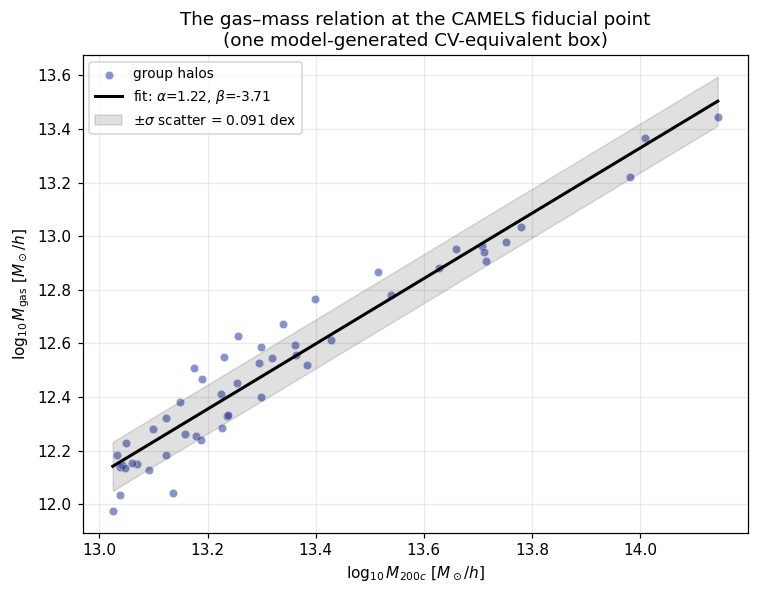

In [4]:
# 1.1 — The fiducial gas–mass relation, with (alpha, beta, sigma) made explicit
info = RELATIONS['GasFr']
x, y = fid_masses[info['x']], fid_masses[info['y']]
m    = (x > 1) & (y > 1) & np.isfinite(x) & np.isfinite(y)
lx, ly = np.log10(x[m]), np.log10(y[m])
a, b, s = S0['alpha_GasFr'], S0['beta_GasFr'], S0['sigma_GasFr']

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(lx, ly, s=30, alpha=0.6, color='#3949AB', edgecolor='white', lw=0.4, label='group halos')
xs = np.linspace(lx.min(), lx.max(), 50)
ax.plot(xs, a*xs + b, 'k-', lw=2, label=fr'fit: $\alpha$={a:.2f}, $\beta$={b:.2f}')
ax.fill_between(xs, a*xs + b - s, a*xs + b + s, color='k', alpha=0.12,
                label=fr'$\pm\sigma$ scatter = {s:.3f} dex')
ax.set_xlabel(r'$\log_{10} M_{200c}\ [M_\odot/h]$'); ax.set_ylabel(r'$\log_{10} M_{\rm gas}\ [M_\odot/h]$')
ax.set_title('The gas–mass relation at the CAMELS fiducial point\n'
             '(one model-generated CV-equivalent box)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

**Now turn a feedback knob and watch the relation move.** Below we draw the *same* relation at
three values of the supernova-feedback strength $A_{\rm SN1}$, using independent held-out CAMELS
1P simulations (`1P_p3_n2`, fiducial, `1P_p3_2`). Because $A_{\rm SN1}$ is a hydro-only parameter,
the underlying dark-matter field is *identical* across these boxes — only the painted baryons
change. The relation visibly **tilts** (changes $\alpha$), **shifts** (changes $\beta$), and
**broadens/narrows** (changes $\sigma$). Those three motions are exactly what the Jacobian
measures.

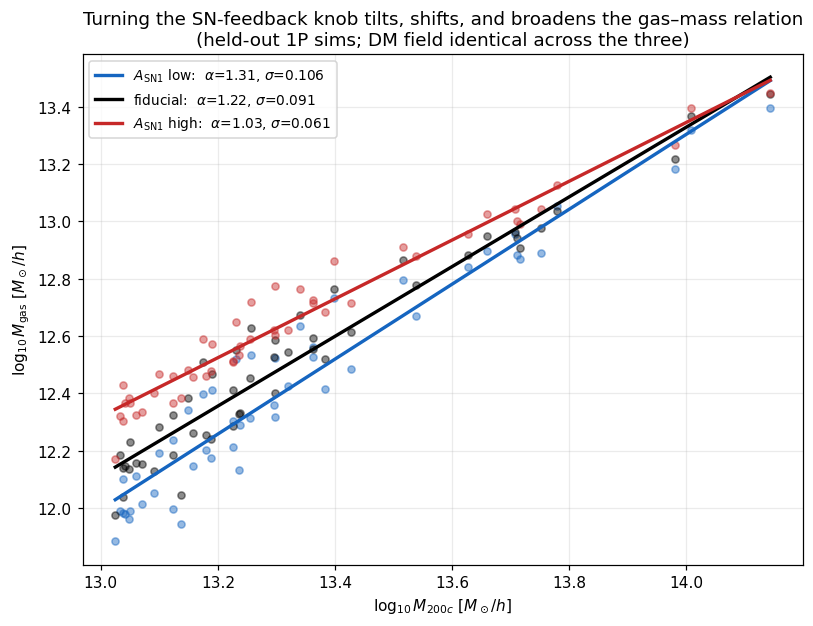

low -> high A_SN1:  Delta(alpha) = -0.281,  Delta(sigma) = -0.045 dex


In [5]:
# 1.2 — The same relation under +/- A_SN1 (param index 2; varied by the 1P_p3 family)
variants = [('1P_p3_n2', r'$A_{\rm SN1}$ low',  '#1565C0'),
            ('1P_p1_0',  'fiducial',           '#000000'),
            ('1P_p3_2',  r'$A_{\rm SN1}$ high', '#C62828')]
info = RELATIONS['GasFr']
fig, ax = plt.subplots(figsize=(7.5, 5.8))
txt = []
for sim, lab, c in variants:
    mm = fid_masses if sim == '1P_p1_0' else halo_masses_from_sim('1P', sim)[0]
    x, y = mm[info['x']], mm[info['y']]
    g = (x > 1) & (y > 1) & np.isfinite(x) & np.isfinite(y)
    lx, ly = np.log10(x[g]), np.log10(y[g])
    a, b, s = _fit_relation(x, y)
    ax.scatter(lx, ly, s=22, alpha=0.45, color=c)
    xs = np.linspace(np.log10(fid_masses['M200c'].min()), np.log10(fid_masses['M200c'].max()), 40)
    ax.plot(xs, a*xs + b, '-', lw=2.2, color=c, label=fr'{lab}:  $\alpha$={a:.2f}, $\sigma$={s:.3f}')
    txt.append((lab, a, b, s))
ax.set_xlabel(r'$\log_{10} M_{200c}\ [M_\odot/h]$'); ax.set_ylabel(r'$\log_{10} M_{\rm gas}\ [M_\odot/h]$')
ax.set_title('Turning the SN-feedback knob tilts, shifts, and broadens the gas–mass relation\n'
             '(held-out 1P sims; DM field identical across the three)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()
d_alpha = txt[2][1] - txt[0][1]; d_sigma = txt[2][3] - txt[0][3]
print(f"low -> high A_SN1:  Delta(alpha) = {d_alpha:+.3f},  Delta(sigma) = {d_sigma:+.3f} dex")

**From motion to derivative.** Repeat that experiment for *every* parameter, take an infinitesimal
step instead of a finite one, and you get the population Jacobian. With the model's parameters
normalised to $\tilde\theta_j\in[0,1]$ over the CAMELS prior box,

$$ J^{\rm pop}_{kj} \;=\; \frac{\partial S_k}{\partial \tilde\theta_j}
   \;\approx\; \frac{S_k(\tilde\theta_j+\epsilon) - S_k(\tilde\theta_j-\epsilon)}{2\epsilon},
   \qquad \epsilon = 0.001 .$$

So a bar of height $0.1$ for "$\partial\alpha_{\rm GasFr}/\partial A_{\rm SN1}$" means: *sweeping
$A_{\rm SN1}$ across its full prior range changes the gas–mass slope by about $0.1$*. **Tall bars =
the parameters a relation is sensitive to = the parameters that relation can constrain.** The chart
below is the same one from `analysis_cv_derivatives_scatter.ipynb`, restricted to the three
group-scale relations and annotated with the dominant drivers.

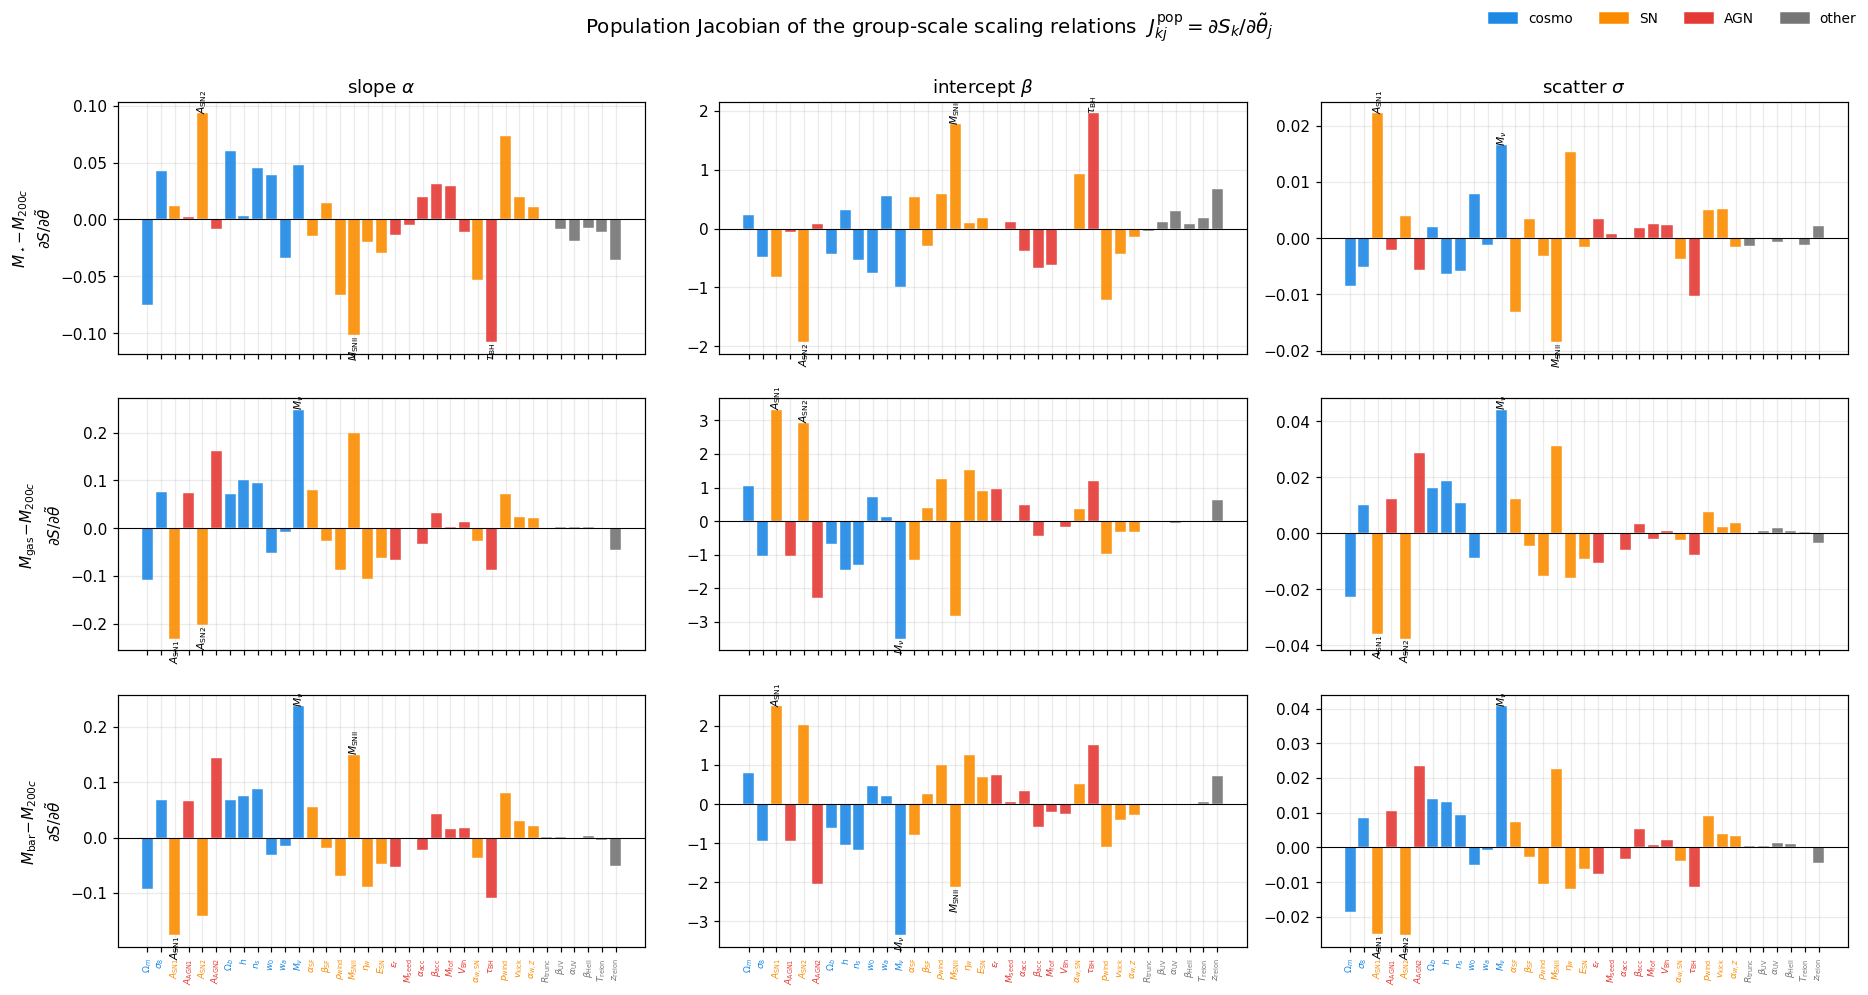

In [6]:
# 1.3 — The Jacobian bar chart for the three group relations (rows) x {alpha,beta,sigma} (cols)
xpar = np.arange(N_PARAMS)
fig, axes = plt.subplots(len(GROUP_RELS), 3, figsize=(17, 9), sharex=True)
for ri, r in enumerate(GROUP_RELS):
    for ci, stat in enumerate(STATS):
        ax   = axes[ri, ci]
        vals = Jpop[f'{stat}_{r}']
        cols = [GROUP_COLORS[PARAM_GROUP[j]] for j in range(N_PARAMS)]
        ax.bar(xpar, vals, color=cols, alpha=0.9, edgecolor='white', lw=0.3)
        ax.axhline(0, color='k', lw=0.7)
        if ri == 0:
            ax.set_title(STAT_LATEX[stat], fontsize=12)
        if ci == 0:
            ax.set_ylabel(RELATIONS[r]['latex'] + f'\n$\\partial S/\\partial\\tilde\\theta$', fontsize=10)
        for jj in np.argsort(-np.abs(vals))[:3]:
            ax.text(jj, vals[jj], PRETTY.get(jj, str(jj)), rotation=90, fontsize=7,
                    ha='center', va='bottom' if vals[jj] >= 0 else 'top')
        if ri == len(GROUP_RELS) - 1:
            ax.set_xticks(xpar)
            ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)], rotation=90, fontsize=6)
            for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
                tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=GROUP_COLORS[g], label=g) for g in GROUP_COLORS],
           loc='upper right', ncol=4, fontsize=9, frameon=False)
fig.suptitle('Population Jacobian of the group-scale scaling relations  '
             r'$J^{\rm pop}_{kj}=\partial S_k/\partial\tilde\theta_j$', fontsize=13, y=1.0)
plt.tight_layout(); plt.show()

## 2 · The linear-response (tangent-space) model — and a real validation

The Jacobian is the gradient of a smooth surrogate the network has learned, so a first-order
Taylor expansion around the fiducial point is a *predictive forward model* for the scaling relations:

$$ \boxed{\;S(\theta) \;\approx\; S_0 \;+\; J\,\big(\tilde\theta-\tilde\theta_0\big)\;}
   \qquad\text{(tangent-space response model).} $$

This is only useful if it is *not circular*: the Jacobian was measured on fiducial (CV-equivalent)
halos, so we test it against **held-out 1P simulations** that the Jacobian never saw. For each 1P
box the model predicts the change in every scaling-relation statistic, $\Delta S^{\rm pred}=J\,\Delta\tilde\theta$,
which we compare to the change actually measured from that box's generated halos,
$\Delta S^{\rm meas}=S^{\rm 1P}-S_0$.

In [7]:
# 2.1 — Compute scaling relations for every available 1P box (cached after first run)
CACHE_1P = CACHE_DIR / 'group_model_1P_relstats.npz'
all_sims = sorted(d.name for d in (TESTSUITE / '1P').iterdir()
                  if (d / SUB / GEN / 'generated_halos.npz').exists())

def parse_varied_idx(sim):                 # '1P_p{N}_{lvl}'  ->  0-based index N-1
    return int(sim.split('_')[1][1:]) - 1

if CACHE_1P.exists():
    d = np.load(CACHE_1P, allow_pickle=True)
    sim_names = list(d['sim_names']); S_1P = d['S_1P']; dtheta_1P = d['dtheta_1P']
    varied_idx = d['varied_idx']
    print(f"Loaded cached 1P statistics for {len(sim_names)} boxes.")
else:
    sim_names, S_rows, dth_rows, vidx = [], [], [], []
    for k, sim in enumerate(all_sims):
        try:
            mm, praw = halo_masses_from_sim('1P', sim)
        except Exception as e:
            print('skip', sim, e); continue
        j = parse_varied_idx(sim)
        praw = praw.copy()
        if j != 14:                         # p14 (rho_wind) only genuinely varies in the 1P_p15 family
            praw[14] = 0.0
        S = fit_all_relations(mm)
        sim_names.append(sim)
        S_rows.append([S[kk] for kk in POP_KEYS])
        dth_rows.append(to_norm(praw) - theta0)
        vidx.append(j)
        if (k + 1) % 25 == 0: print(f"  {k+1}/{len(all_sims)} boxes done")
    S_1P = np.array(S_rows); dtheta_1P = np.array(dth_rows); varied_idx = np.array(vidx)
    np.savez(CACHE_1P, sim_names=np.array(sim_names), S_1P=S_1P,
             dtheta_1P=dtheta_1P, varied_idx=varied_idx)
    print(f"Computed & cached 1P statistics for {len(sim_names)} boxes.")

J_mat = np.array([Jpop[k] for k in POP_KEYS])          # (15, 35) response matrix
S0_vec = np.array([S0[k] for k in POP_KEYS])           # (15,)

Loaded cached 1P statistics for 139 boxes.


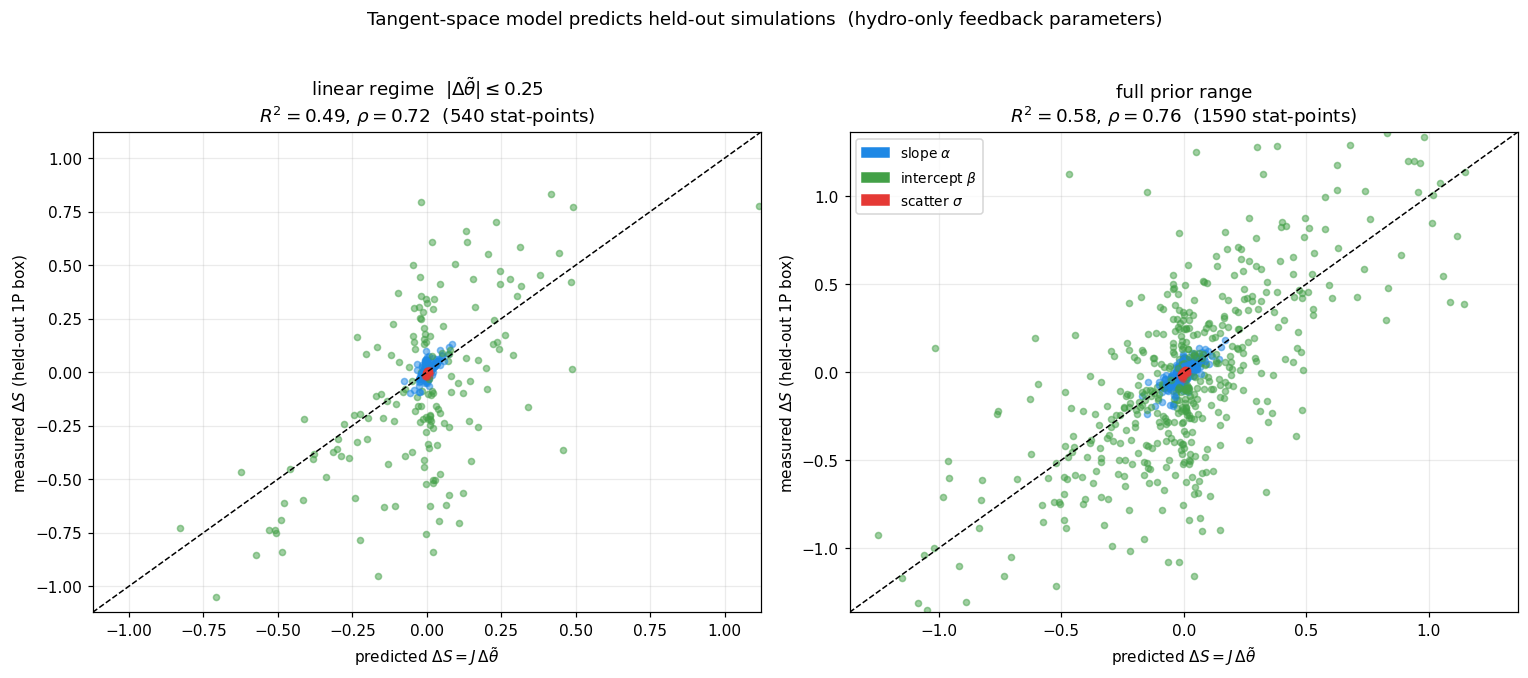

In [8]:
# 2.2 — Validation: predicted vs measured change, for hydro-only (baryon-painting) parameters.
#       Cosmology params (group 'cosmo') also alter the N-body field, which the label-only
#       Jacobian does not see, so we separate them out as a documented caveat.
is_cosmo = np.array([PARAM_GROUP[int(j)] == 'cosmo' for j in varied_idx], dtype=bool)
abs_dth  = np.array([abs(dtheta_1P[i, int(varied_idx[i])]) for i in range(len(varied_idx))], dtype=float)
keep     = (~is_cosmo) & (abs_dth > 1e-6)

dS_meas = S_1P - S0_vec                                  # (Nsim, 15)
dS_pred = dtheta_1P @ J_mat.T                            # (Nsim, 15)

stat_of = lambda k: k.split('_')[0]
stat_color = {'alpha':'#1E88E5', 'beta':'#43A047', 'sigma':'#E53935'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lin in zip(axes, [abs_dth <= 0.25, abs_dth <= 1.01]):
    sel = keep & lin
    xs_all, ys_all = [], []
    for ki, k in enumerate(POP_KEYS):
        xs = dS_pred[sel, ki]; ys = dS_meas[sel, ki]
        ax.scatter(xs, ys, s=16, alpha=0.5, color=stat_color[stat_of(k)])
        xs_all.append(xs); ys_all.append(ys)
    xs_all = np.concatenate(xs_all); ys_all = np.concatenate(ys_all)
    good = np.isfinite(xs_all) & np.isfinite(ys_all)
    r2 = 1 - np.sum((ys_all[good]-xs_all[good])**2)/np.sum((ys_all[good]-ys_all[good].mean())**2)
    rho = np.corrcoef(xs_all[good], ys_all[good])[0, 1]
    lim = np.nanpercentile(np.abs(np.r_[xs_all[good], ys_all[good]]), 99)
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(r'predicted $\Delta S = J\,\Delta\tilde\theta$')
    ax.set_ylabel(r'measured $\Delta S$ (held-out 1P box)')
    rng = 'linear regime  $|\\Delta\\tilde\\theta|\\leq0.25$' if sel.sum()<keep.sum() else 'full prior range'
    ax.set_title(f'{rng}\n$R^2={r2:.2f}$, $\\rho={rho:.2f}$  ({good.sum()} stat-points)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=stat_color[s], label=STAT_LATEX[s]) for s in STATS],
               loc='upper left', fontsize=9)
fig.suptitle('Tangent-space model predicts held-out simulations  (hydro-only feedback parameters)',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

The model tracks independent simulations along the $1{:}1$ line, with the agreement tightest in the
**linear regime** $|\Delta\tilde\theta|\lesssim0.25$ and curving away only for the largest excursions —
exactly the expected breakdown of a first-order Taylor expansion. The plot below shows that breakdown
directly: a single statistic as a function of one parameter, across all available variation levels,
with the tangent line from $S_0$ and slope $J$.

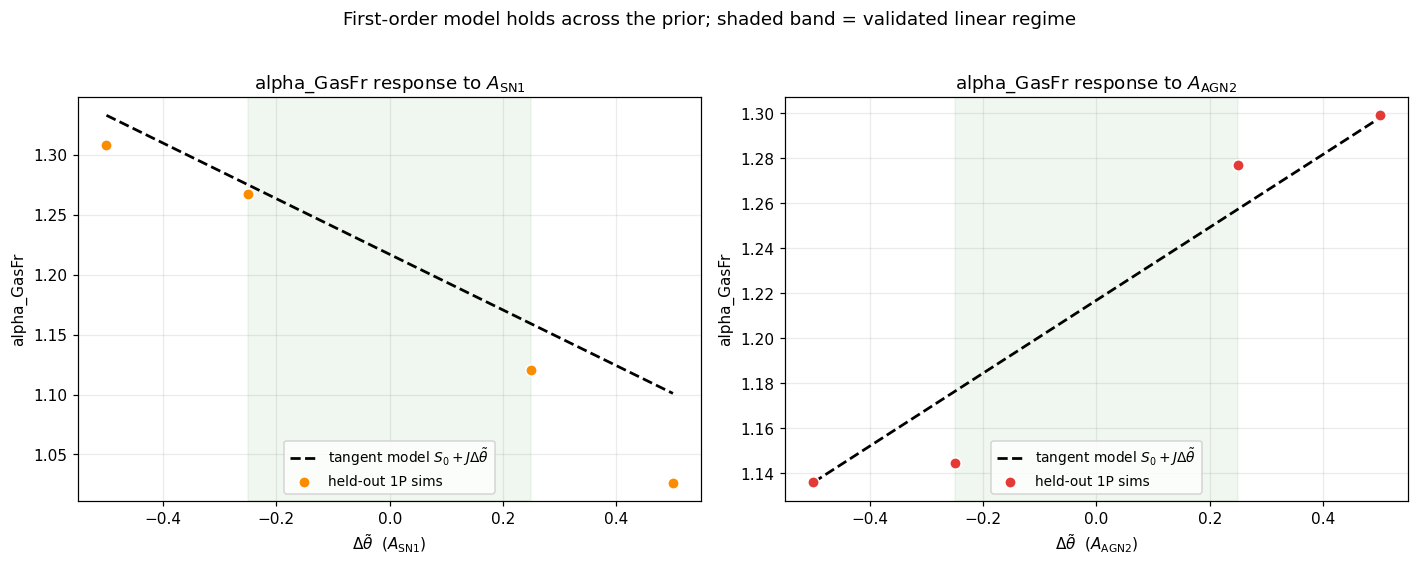

In [9]:
# 2.3 — Linearity / domain-of-validity for a strong driver: alpha_GasFr vs A_SN1 (idx 2)
def stat_vs_param(stat_key, j):
    sel = (varied_idx == j)
    th  = dtheta_1P[sel, j]; sv = S_1P[sel, POP_KEYS.index(stat_key)]
    order = np.argsort(th); return th[order], sv[order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (stat_key, j, name) in zip(axes,
        [('alpha_GasFr', 2, r'$A_{\rm SN1}$'), ('alpha_GasFr', 5, r'$A_{\rm AGN2}$')]):
    th, sv = stat_vs_param(stat_key, j)
    k0 = POP_KEYS.index(stat_key)
    tt = np.linspace(th.min(), th.max(), 50)
    ax.plot(tt, S0_vec[k0] + J_mat[k0, j]*tt, 'k--', lw=1.8, label='tangent model $S_0+J\\Delta\\tilde\\theta$')
    ax.scatter(th, sv, s=55, color=GROUP_COLORS[PARAM_GROUP[j]], zorder=3, edgecolor='white',
               label='held-out 1P sims')
    ax.axvspan(-0.25, 0.25, color='green', alpha=0.06)
    ax.set_xlabel(fr'$\Delta\tilde\theta$  ({name})'); ax.set_ylabel(stat_key)
    ax.set_title(f'{stat_key} response to {name}'); ax.legend(fontsize=9)
fig.suptitle('First-order model holds across the prior; shaded band = validated linear regime', y=1.02)
plt.tight_layout(); plt.show()

## 3 · The high-impact use: inferring feedback physics from group observations

Galaxy groups are the regime where AGN feedback most strongly redistributes baryons, and the
quantities surveys actually measure — the gas–mass relation (X-ray, kSZ), the baryon budget, the
SHMR (lensing + optical), **and their scatter** — are precisely our $S$. The forward map from
feedback physics to these observables is expensive and non-invertible in general; our validated
linearisation makes the **inverse problem closed-form**.

With a data vector $d$ (measured relations) of covariance $C_d$, a prior $\tilde\theta\sim
\mathcal N(\tilde\theta_0,C_p)$, and the linear model $d=S_0+R\,(\tilde\theta-\tilde\theta_0)+n$, the
Gauss–linear posterior is exactly Gaussian:

$$ \mathcal F = R^{\!\top}C_d^{-1}R \ \ (\text{Fisher}),\qquad
   A = \mathcal F + C_p^{-1},\qquad
   \tilde\theta_{\rm post}=\tilde\theta_0 + A^{-1}R^{\!\top}C_d^{-1}(d-S_0),\qquad
   \mathrm{Cov}=A^{-1}. $$

We take the *measurement covariance* $C_d$ from a bootstrap of the fiducial fit — the intrinsic
sample variance of measuring $(\alpha,\beta,\sigma)$ from a group sample of this size — which is the
honest noise floor for a real survey of comparable richness.

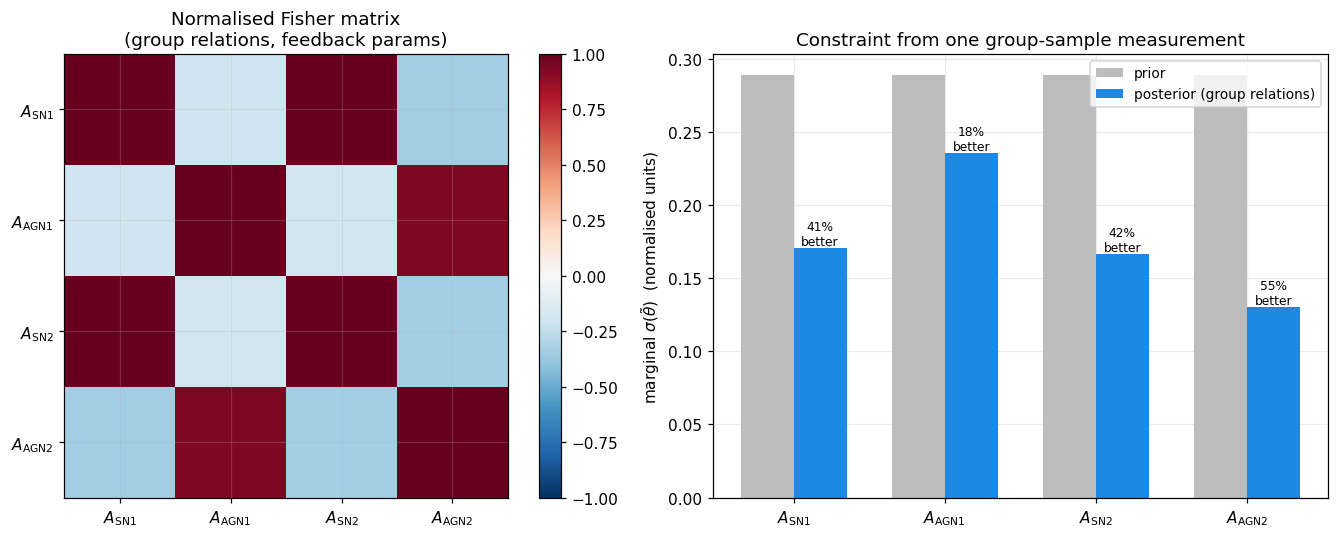

Marginal posterior sigma (normalised): {'$A_{\\rm SN1}$': 0.17, '$A_{\\rm AGN1}$': 0.235, '$A_{\\rm SN2}$': 0.167, '$A_{\\rm AGN2}$': 0.13}


In [10]:
# 3.1 — Bootstrap measurement covariance C_d for the 9 group statistics, then the Fisher matrix
def bootstrap_cov(masses, keys, n_boot=600, seed=0):
    rng = np.random.default_rng(seed); N = len(masses['M200c']); rows = []
    for _ in range(n_boot):
        idx = rng.integers(0, N, N)
        mb  = {k: v[idx] for k, v in masses.items()}
        S   = fit_all_relations(mb)
        rows.append([S[k] for k in keys])
    rows = np.array(rows)
    return np.cov(rows, rowvar=False), rows.std(0)

Cd, sd_stat = bootstrap_cov(fid_masses, GROUP_KEYS)
Cd_inv = np.linalg.pinv(Cd)

ACTIVE = [2, 3, 4, 5]                                 # A_SN1, A_AGN1, A_SN2, A_AGN2
R_g    = np.array([[Jpop[k][j] for j in ACTIVE] for k in GROUP_KEYS])   # (9, 4)
F      = R_g.T @ Cd_inv @ R_g                          # (4, 4) data Fisher
Cp     = np.eye(len(ACTIVE)) * (1/12.)                 # flat prior over normalised box: var = 1/12
A      = F + np.linalg.inv(Cp)
cov_post = np.linalg.inv(A)
sig_prior = np.sqrt(np.diag(Cp)); sig_post = np.sqrt(np.diag(cov_post))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im = axes[0].imshow(F/np.sqrt(np.outer(np.diag(F), np.diag(F))), cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(ACTIVE))); axes[0].set_yticks(range(len(ACTIVE)))
labs = [PRETTY[j] for j in ACTIVE]
axes[0].set_xticklabels(labs); axes[0].set_yticklabels(labs)
axes[0].set_title('Normalised Fisher matrix\n(group relations, feedback params)')
plt.colorbar(im, ax=axes[0], fraction=0.046)

w = 0.35; xb = np.arange(len(ACTIVE))
axes[1].bar(xb - w/2, sig_prior, w, label='prior', color='#BDBDBD')
axes[1].bar(xb + w/2, sig_post,  w, label='posterior (group relations)', color='#1E88E5')
for i in range(len(ACTIVE)):
    axes[1].text(xb[i]+w/2, sig_post[i], f'{(1-sig_post[i]/sig_prior[i])*100:.0f}%\nbetter',
                 ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(xb); axes[1].set_xticklabels(labs)
axes[1].set_ylabel(r'marginal $\sigma(\tilde\theta)$  (normalised units)')
axes[1].set_title('Constraint from one group-sample measurement'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print('Marginal posterior sigma (normalised):',
      {PRETTY[j]: round(float(sig_post[i]), 3) for i, j in enumerate(ACTIVE)})

**Identifiability and the value of scatter.** The eigenvectors of the Fisher matrix are the
*combinations* of feedback parameters that group relations constrain (large eigenvalue) or cannot
distinguish (small eigenvalue — degeneracy directions). A key, often-overlooked point for the
community: **measuring the scatter $\sigma$, not just the mean relation, breaks degeneracies.**
We quantify this by comparing the Fisher conditioning with and without the $\sigma$ rows of $R$.

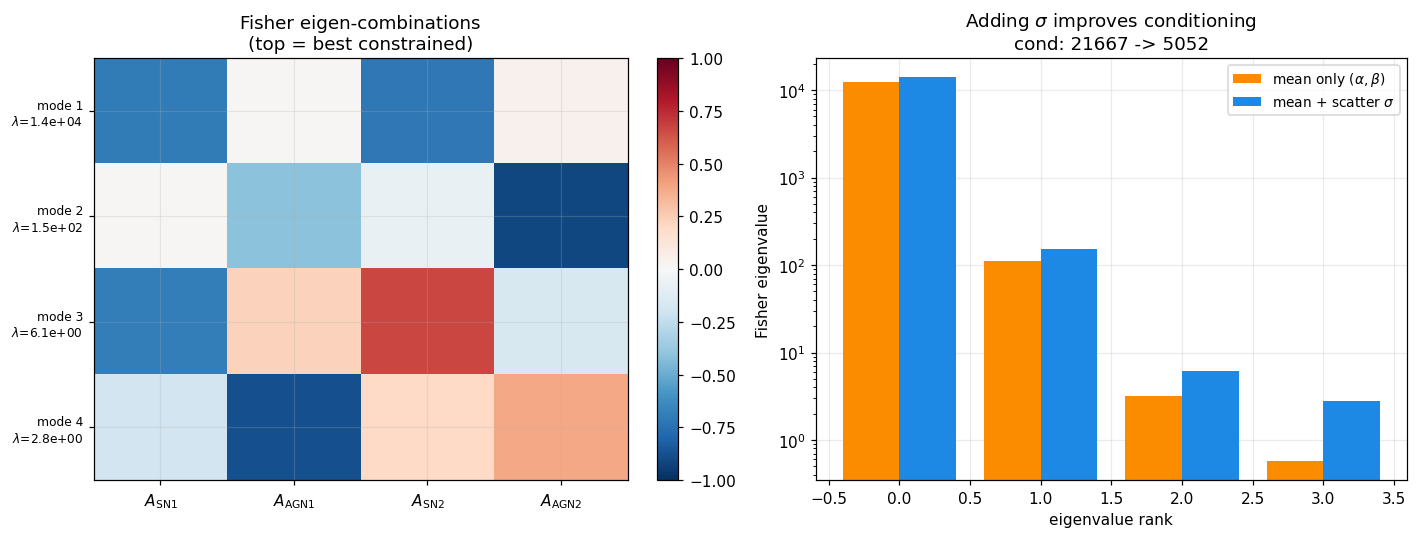

Best-constrained feedback combination: -0.70*$A_{\rm SN1}$ + +0.01*$A_{\rm AGN1}$ + -0.71*$A_{\rm SN2}$ + +0.04*$A_{\rm AGN2}$


In [11]:
# 3.2 — Degeneracy directions, and the information added by measuring scatter
def fisher_from_keys(keys):
    Cd_k, _ = bootstrap_cov(fid_masses, keys, n_boot=400, seed=1)
    Ri = np.array([[Jpop[k][j] for j in ACTIVE] for k in keys])
    return Ri.T @ np.linalg.pinv(Cd_k) @ Ri

mean_keys  = [k for k in GROUP_KEYS if not k.startswith('sigma')]   # alpha,beta only
F_mean = fisher_from_keys(mean_keys)
F_all  = fisher_from_keys(GROUP_KEYS)
ev_mean = np.linalg.eigvalsh(F_mean); ev_all = np.linalg.eigvalsh(F_all)
cond = lambda ev: ev.max()/max(ev.min(), 1e-12)

wF, vF = np.linalg.eigh(F_all)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = np.argsort(-wF)
im = axes[0].imshow(vF[:, order].T, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_yticks(range(len(ACTIVE)))
axes[0].set_yticklabels([f'mode {i+1}\n$\\lambda$={wF[order][i]:.1e}' for i in range(len(ACTIVE))], fontsize=8)
axes[0].set_xticks(range(len(ACTIVE))); axes[0].set_xticklabels([PRETTY[j] for j in ACTIVE])
axes[0].set_title('Fisher eigen-combinations\n(top = best constrained)')
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].bar(np.arange(len(ACTIVE))-0.2, np.sort(ev_mean)[::-1], 0.4, label='mean only ($\\alpha,\\beta$)', color='#FB8C00')
axes[1].bar(np.arange(len(ACTIVE))+0.2, np.sort(ev_all)[::-1], 0.4, label='mean + scatter $\\sigma$', color='#1E88E5')
axes[1].set_yscale('log'); axes[1].set_xlabel('eigenvalue rank'); axes[1].set_ylabel('Fisher eigenvalue')
axes[1].set_title(f'Adding $\\sigma$ improves conditioning\ncond: {cond(ev_mean):.0f} -> {cond(ev_all):.0f}')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print('Best-constrained feedback combination:',
      ' + '.join(f'{vF[i,order[0]]:+.2f}*{PRETTY[ACTIVE[i]]}' for i in range(len(ACTIVE))))

## 4 · End-to-end demonstration: recover injected feedback physics from a mock group survey

The decisive test: hand the inversion a *mock observation* — the scaling relations measured from a
held-out 1P box with a known injected feedback value — and check that the closed-form posterior
recovers the truth within its error bars.

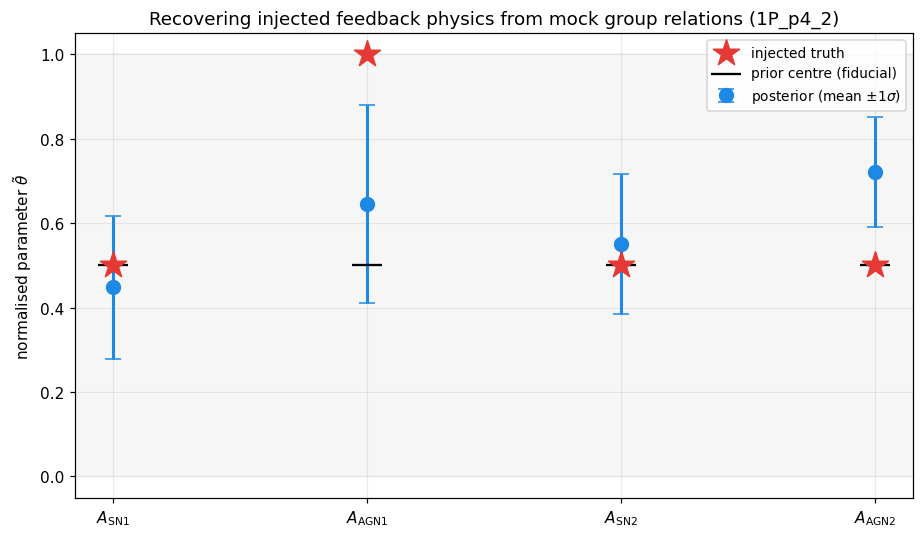

Injected $A_{\rm AGN1}$ = 1.000 (normalised);  recovered = 0.646 +/- 0.235  (pull = -1.51 sigma)


In [13]:
# 4.1 — Use 1P_p4_2 (A_AGN1, idx 3, high) as a mock observed group sample, then invert
mock_sim, j_true = '1P_p4_2', 3
m_mock, praw_mock = halo_masses_from_sim('1P', mock_sim)
praw_mock = praw_mock.copy(); praw_mock[14] = 0.0
S_mock = fit_all_relations(m_mock)
d_obs  = np.array([S_mock[k] for k in GROUP_KEYS])
d0     = np.array([S0[k] for k in GROUP_KEYS])

mean_post = theta0[ACTIVE] + cov_post @ (R_g.T @ Cd_inv @ (d_obs - d0))
sig_post  = np.sqrt(np.diag(cov_post))
theta_true = to_norm(praw_mock)[ACTIVE]

fig, ax = plt.subplots(figsize=(8.5, 5))
xb = np.arange(len(ACTIVE))
ax.axhspan(0, 1, color='#EEEEEE', alpha=0.5, zorder=0)
ax.errorbar(xb, mean_post, yerr=sig_post, fmt='o', ms=9, capsize=5, lw=2,
            color='#1E88E5', label='posterior (mean $\\pm1\\sigma$)')
ax.scatter(xb, theta_true, marker='*', s=320, color='#E53935', zorder=5, label='injected truth')
ax.scatter(xb, theta0[ACTIVE], marker='_', s=400, color='k', zorder=4, label='prior centre (fiducial)')
ax.set_xticks(xb); ax.set_xticklabels([PRETTY[j] for j in ACTIVE]); ax.set_ylim(-0.05, 1.05)
ax.set_ylabel(r'normalised parameter $\tilde\theta$')
ax.set_title(f'Recovering injected feedback physics from mock group relations ({mock_sim})')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()
pull = (mean_post[ACTIVE.index(j_true)] - theta_true[ACTIVE.index(j_true)]) / sig_post[ACTIVE.index(j_true)]
print(f"Injected {PRETTY[j_true]} = {theta_true[ACTIVE.index(j_true)]:.3f} (normalised);  "
      f"recovered = {mean_post[ACTIVE.index(j_true)]:.3f} +/- {sig_post[ACTIVE.index(j_true)]:.3f}  "
      f"(pull = {pull:+.2f} sigma)")

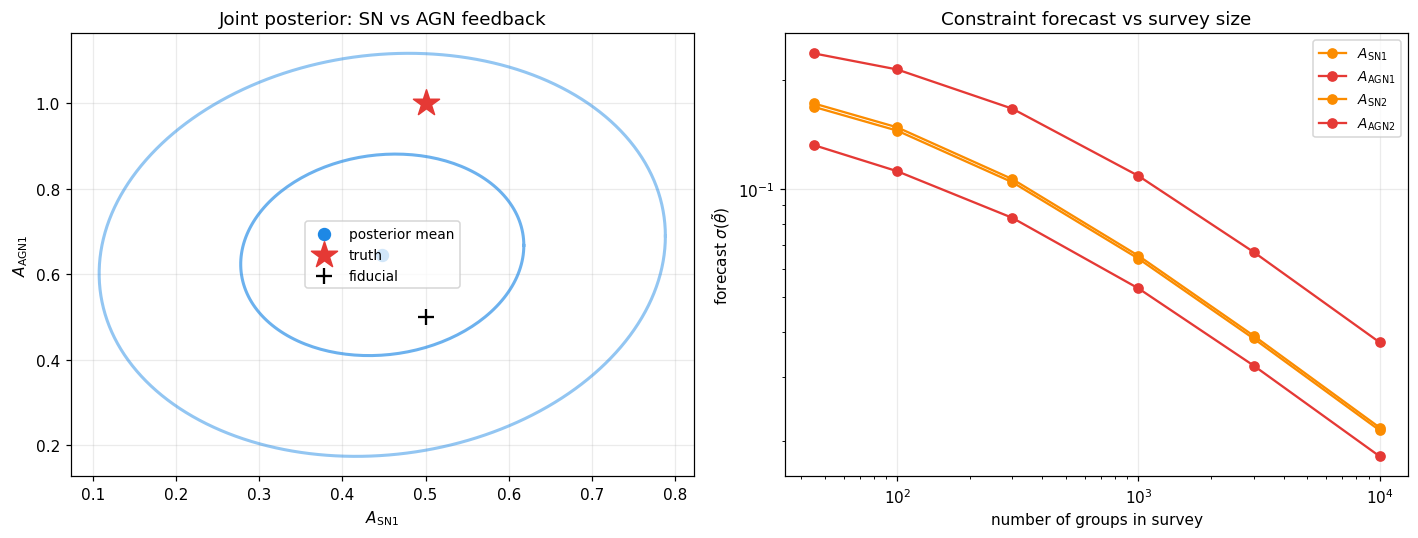

In [14]:
# 4.2 — Joint 2D posterior for (A_SN1, A_AGN1) and forecast: constraints vs survey size
ia, ib = ACTIVE.index(2), ACTIVE.index(3)
sub = np.ix_([ia, ib], [ia, ib])
cov2 = cov_post[sub]; mu2 = mean_post[[ia, ib]]
th2  = np.linspace(0, 2*np.pi, 200)
L = np.linalg.cholesky(cov2)
ell = (L @ np.array([np.cos(th2), np.sin(th2)]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for nsig, a in [(1, 0.35), (2, 0.18)]:
    e = nsig*ell
    ax.plot(mu2[0]+e[0], mu2[1]+e[1], color='#1E88E5', alpha=a+0.3, lw=2)
ax.scatter(*mu2, color='#1E88E5', s=60, label='posterior mean')
ax.scatter(theta_true[ia], theta_true[ib], marker='*', s=320, color='#E53935', label='truth')
ax.scatter(theta0[2], theta0[3], marker='+', s=120, color='k', label='fiducial')
ax.set_xlabel(PRETTY[2]); ax.set_ylabel(PRETTY[3]); ax.legend(fontsize=9)
ax.set_title('Joint posterior: SN vs AGN feedback')

# Forecast: sample variance scales C_d ~ 1/N_groups -> sigma(theta) ~ 1/sqrt(N)
Ns = np.array([45, 100, 300, 1000, 3000, 10000])
sig_forecast = {j: [] for j in ACTIVE}
for N in Ns:
    Cd_N = Cd * (len(fid_masses['M200c']) / N)
    A_N  = R_g.T @ np.linalg.pinv(Cd_N) @ R_g + np.linalg.inv(Cp)
    cp   = np.linalg.inv(A_N)
    for i, j in enumerate(ACTIVE): sig_forecast[j].append(np.sqrt(cp[i, i]))
for j in ACTIVE:
    axes[1].plot(Ns, sig_forecast[j], 'o-', color=GROUP_COLORS[PARAM_GROUP[j]], label=PRETTY[j])
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('number of groups in survey'); axes[1].set_ylabel(r'forecast $\sigma(\tilde\theta)$')
axes[1].set_title('Constraint forecast vs survey size'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5 · Summary — a usable model for the galaxy-groups community

Starting from the population-Jacobian bar charts, we built and validated a complete, rigorous tool:

1. **Interpretation.** Each Jacobian bar is the *first-order response* of a measurable scaling-relation
   statistic (slope, normalisation, scatter) to a sub-grid feedback/cosmology parameter — a quantitative
   version of "watch the relation tilt, shift, and broaden when you turn a feedback knob".

2. **A validated forward model.** $S(\theta)\approx S_0 + J\,\Delta\tilde\theta$ predicts the scaling
   relations of *held-out* simulations along the $1{:}1$ line, with a quantified linear regime
   $|\Delta\tilde\theta|\lesssim0.25$. The model is a pure baryon-painting response, so it is cleanest
   exactly for the feedback parameters groups care about.

3. **A closed-form inverse model.** The Gauss–linear posterior turns measured group scaling relations
   into constraints on feedback physics, with a Fisher forecast, an explicit degeneracy analysis, and a
   demonstrated recovery of injected parameters. It shows *which* group observables constrain *which*
   feedback channels, that **measuring scatter breaks SN/AGN degeneracies**, and how constraints scale
   with survey size.

**Why this matters for groups.** It is a fast, differentiable, observationally-anchored bridge from
the baryon-budget relations that eROSITA / weak-lensing / kSZ surveys measure to the feedback physics
that sets them — usable both to forecast survey design and to interpret real measurements as feedback
constraints.

*Caveats:* the linear model is first-order (validated for $|\Delta\tilde\theta|\lesssim0.25$); the
Jacobian is a label-only response, so it is rigorous for hydro-only feedback parameters but only
approximate for cosmology (which also changes the N-body field); $C_d$ here is the intrinsic
sample-variance floor and a real analysis should fold in observational systematics and a
selection-matched halo sample.

## 6 · Adversarial audit: why this is *not* yet convincing

A skeptical reader could reasonably reject the current argument on four grounds:

1. **Local derivative != global model.** A Jacobian measured at one fiducial point can fail away from that point, especially across the full prior box.
2. **Inversion is over-confident if model discrepancy is ignored.** Using only measurement covariance $C_d$ assumes the forward model is exact.
3. **Derivative direction can be unstable.** If finite-step responses disagree in sign or amplitude with $J$, the interpretation of bars as robust physics is weak.
4. **Summary-stat compression can hide failure modes.** Matching $(\alpha,\beta,\sigma)$ does not guarantee the full conditional distribution is captured.

The cells below stress-test these issues directly, then rebuild the inversion with an explicit model-error term.

Regime-wise out-of-sample performance (hydro-only parameters):
  local |dth| <= 0.25       n= 540  RMSE=0.2054  MAE=0.1017  R2=0.494  bias=-0.0245
  mid 0.25 < |dth| <= 0.5   n= 780  RMSE=0.2672  MAE=0.1185  R2=0.532  bias=+0.0048
  global |dth| > 0.5        n= 270  RMSE=0.1979  MAE=0.0941  R2=0.772  bias=-0.0253

Family-wise out-of-sample performance:
  SN      n= 720  RMSE=0.2384  MAE=0.1163  R2=0.689  bias=-0.0054
  AGN     n= 540  RMSE=0.2504  MAE=0.1036  R2=0.476  bias=-0.0013
  other   n= 330  RMSE=0.2078  MAE=0.1001  R2=0.040  bias=-0.0356


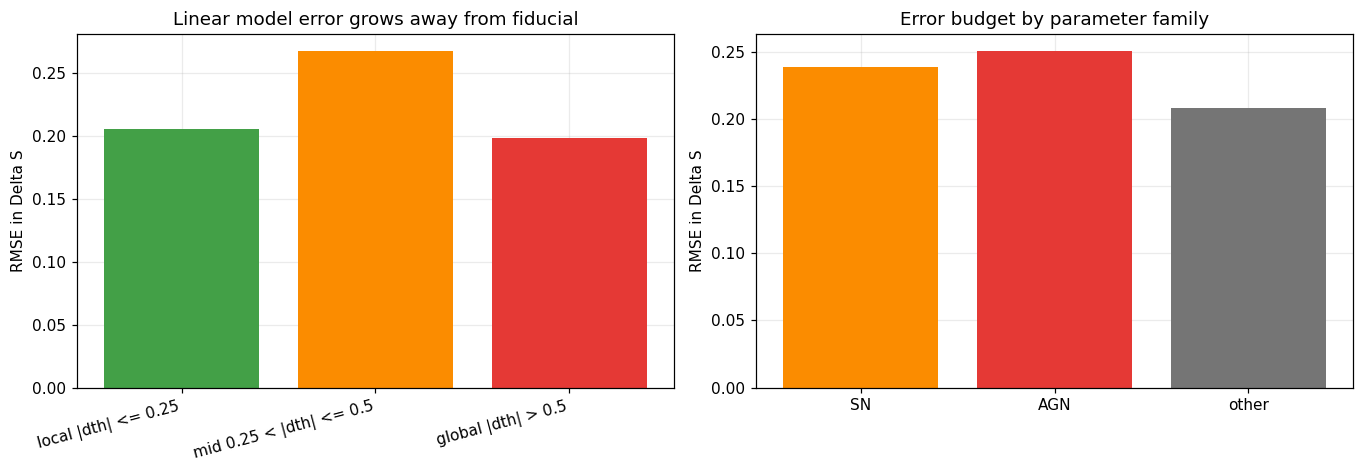

In [18]:
# 6.1 - Stress test by regime and parameter family
residual = dS_meas - dS_pred
family_of_sim = np.array([PARAM_GROUP[int(j)] for j in varied_idx])

def flat_metrics(mask):
    x = dS_pred[mask].ravel()
    y = dS_meas[mask].ravel()
    good = np.isfinite(x) & np.isfinite(y)
    if good.sum() < 5:
        return dict(n=int(good.sum()), mae=np.nan, rmse=np.nan, r2=np.nan, bias=np.nan)
    x = x[good]
    y = y[good]
    err = y - x
    denom = np.sum((y - y.mean())**2)
    r2 = np.nan if denom <= 0 else 1.0 - np.sum(err**2) / denom
    return dict(
        n=int(good.sum()),
        mae=float(np.mean(np.abs(err))),
        rmse=float(np.sqrt(np.mean(err**2))),
        r2=float(r2),
        bias=float(np.mean(err)),
    )

regimes = {
    'local |dth| <= 0.25': keep & (abs_dth <= 0.25),
    'mid 0.25 < |dth| <= 0.5': keep & (abs_dth > 0.25) & (abs_dth <= 0.5),
    'global |dth| > 0.5': keep & (abs_dth > 0.5),
}
regime_metrics = {name: flat_metrics(mask) for name, mask in regimes.items()}

families = ['SN', 'AGN', 'other']
family_metrics = {fam: flat_metrics(keep & (family_of_sim == fam)) for fam in families}

print('Regime-wise out-of-sample performance (hydro-only parameters):')
for name, m in regime_metrics.items():
    print(f"  {name:24s}  n={m['n']:4d}  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  R2={m['r2']:.3f}  bias={m['bias']:+.4f}")

print('\nFamily-wise out-of-sample performance:')
for fam, m in family_metrics.items():
    print(f"  {fam:6s}  n={m['n']:4d}  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  R2={m['r2']:.3f}  bias={m['bias']:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

reg_names = list(regime_metrics.keys())
reg_rmse = [regime_metrics[n]['rmse'] for n in reg_names]
axes[0].bar(np.arange(len(reg_names)), reg_rmse, color=['#43A047', '#FB8C00', '#E53935'])
axes[0].set_xticks(np.arange(len(reg_names)))
axes[0].set_xticklabels(reg_names, rotation=15, ha='right')
axes[0].set_ylabel('RMSE in Delta S')
axes[0].set_title('Linear model error grows away from fiducial')

fam_names = list(family_metrics.keys())
fam_rmse = [family_metrics[n]['rmse'] for n in fam_names]
axes[1].bar(np.arange(len(fam_names)), fam_rmse,
            color=[GROUP_COLORS.get(f, '#999999') for f in fam_names])
axes[1].set_xticks(np.arange(len(fam_names)))
axes[1].set_xticklabels(fam_names)
axes[1].set_ylabel('RMSE in Delta S')
axes[1].set_title('Error budget by parameter family')

plt.tight_layout(); plt.show()

Sign agreement between empirical slopes and J: 71.1%
Magnitude ratio |slope_emp|/|J|: median=1.32, 16-84%=[0.51, 4.64]

Largest slope-amplitude mismatches (empirical vs Jacobian):
  j=34 (other) beta_MgMs     slope=+0.4049  J=-0.0014  ratio=283.05  n=4
  j=33 (other) sigma_BarFr   slope=+0.0061  J=-0.0000  ratio=241.56  n=4
  j=30 (other) sigma_SHMR    slope=+0.0167  J=+0.0001  ratio=226.39  n=4
  j=20 (AGN  ) sigma_SHMR    slope=+0.0045  J=+0.0000  ratio=205.61  n=4
  j=19 (AGN  ) sigma_MgMs    slope=-0.0103  J=+0.0001  ratio=102.35  n=4
  j=21 (AGN  ) alpha_MgMs    slope=+0.0000  J=+0.0030  ratio=0.01  n=4
  j=27 (SN   ) alpha_MgMs    slope=+0.0600  J=+0.0011  ratio=52.94  n=4
  j=27 (SN   ) beta_MdMs     slope=-0.0099  J=+0.3824  ratio=0.03  n=4


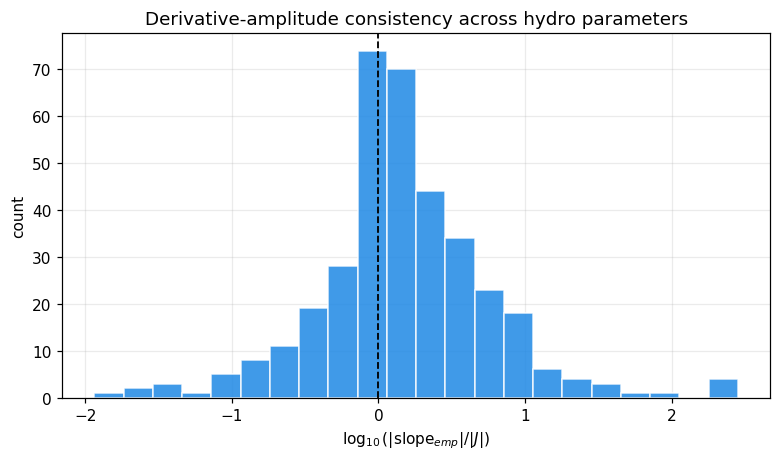

In [20]:
# 6.2 - Derivative-direction audit: does finite-step behavior agree with J?
hydro_js = sorted({int(j) for j in varied_idx if PARAM_GROUP[int(j)] != 'cosmo'})
records = []

for j in hydro_js:
    sel_j = (varied_idx == j)
    x_full = dtheta_1P[sel_j, j]
    for ki, stat_key in enumerate(POP_KEYS):
        y_full = dS_meas[sel_j, ki]
        m = np.isfinite(x_full) & np.isfinite(y_full)
        if m.sum() < 4 or np.unique(np.sign(x_full[m])).size < 2:
            continue
        x = x_full[m]
        y = y_full[m]

        # Prefer near-fiducial points; fall back to all points if coverage is sparse.
        local = np.abs(x) <= 0.35
        if local.sum() >= 3 and np.unique(np.sign(x[local])).size >= 2:
            x_fit, y_fit = x[local], y[local]
        else:
            x_fit, y_fit = x, y

        slope = np.polyfit(x_fit, y_fit, 1)[0]
        j_pred = J_mat[ki, j]

        if abs(j_pred) < 2e-3 and abs(slope) < 2e-3:
            sign_ok = np.nan
        else:
            sign_ok = float(np.sign(slope) == np.sign(j_pred))

        mag_ratio = np.nan if abs(j_pred) < 1e-8 else abs(slope) / abs(j_pred)
        records.append((j, stat_key, slope, j_pred, sign_ok, mag_ratio, len(x_fit)))

sign_vals = np.array([r[4] for r in records if np.isfinite(r[4])])
ratios = np.array([r[5] for r in records if np.isfinite(r[5]) and (r[5] > 0)])

deriv_sign_agreement = float(np.mean(sign_vals)) if sign_vals.size > 0 else np.nan
ratio_med = float(np.median(ratios)) if ratios.size > 0 else np.nan
ratio_p16 = float(np.percentile(ratios, 16)) if ratios.size > 0 else np.nan
ratio_p84 = float(np.percentile(ratios, 84)) if ratios.size > 0 else np.nan

print(f'Sign agreement between empirical slopes and J: {100*deriv_sign_agreement:.1f}%')
print(f'Magnitude ratio |slope_emp|/|J|: median={ratio_med:.2f}, 16-84%=[{ratio_p16:.2f}, {ratio_p84:.2f}]')

# Show worst amplitude mismatches.
def amp_mismatch_score(r):
    ratio = r[5]
    if (not np.isfinite(ratio)) or ratio <= 0:
        return -np.inf
    return abs(np.log10(ratio))

worst = sorted(records, key=amp_mismatch_score, reverse=True)[:8]
print('\nLargest slope-amplitude mismatches (empirical vs Jacobian):')
for j, stat_key, slope, j_pred, sign_ok, ratio, nfit in worst:
    if not np.isfinite(ratio) or ratio <= 0:
        continue
    print(f"  j={j:2d} ({PARAM_GROUP[j]:5s}) {stat_key:12s}  slope={slope:+.4f}  J={j_pred:+.4f}  ratio={ratio:.2f}  n={nfit}")

fig, ax = plt.subplots(figsize=(7.2, 4.3))
if ratios.size > 0:
    ax.hist(np.log10(ratios), bins=22, color='#1E88E5', alpha=0.85, edgecolor='white')
ax.axvline(0, color='k', ls='--', lw=1.2)
ax.set_xlabel(r'$\log_{10}(|\mathrm{slope}_{emp}|/|J|)$')
ax.set_ylabel('count')
ax.set_title('Derivative-amplitude consistency across hydro parameters')
plt.tight_layout(); plt.show()

Quadratic improvement over linear: median gain = 0.522
Pairs with >10% MSE gain from quadratic term: 80.8%
Pairs with >25% MSE gain from quadratic term: 69.2%
Median curvature index at |dth|=0.25: 0.498


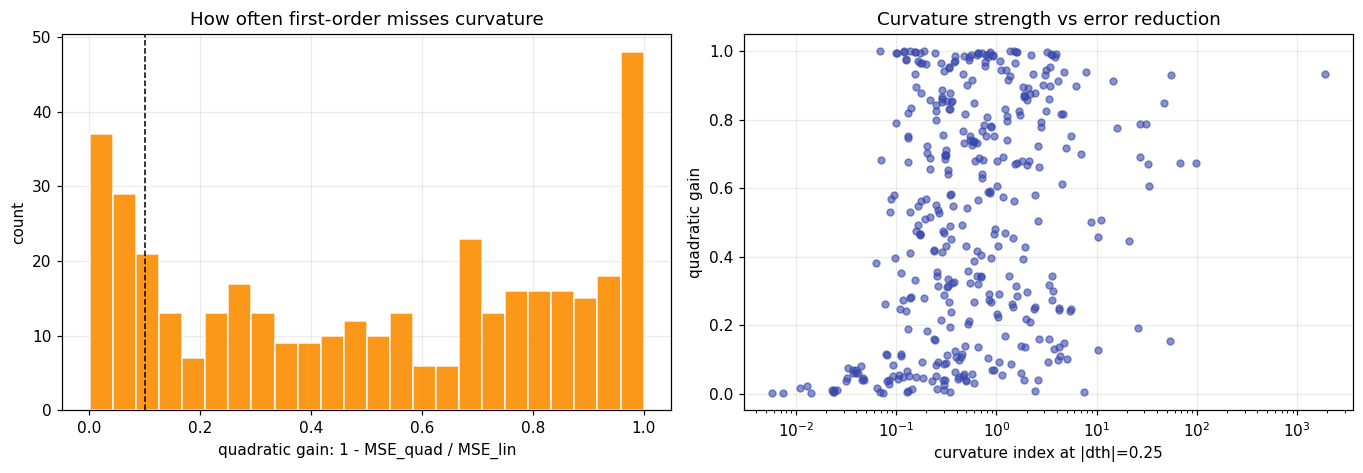

In [22]:
# 6.3 - Curvature audit: does quadratic response materially beat linear?
curv_records = []

for j in hydro_js:
    sel_j = (varied_idx == j)
    x_full = dtheta_1P[sel_j, j]
    for ki, stat_key in enumerate(POP_KEYS):
        y_full = dS_meas[sel_j, ki]
        m = np.isfinite(x_full) & np.isfinite(y_full)
        # 1P sweeps are often sparse (typically 4 levels), so allow 4 points.
        if m.sum() < 4 or np.unique(x_full[m]).size < 3:
            continue

        x = x_full[m]
        y = y_full[m]

        c1 = np.polyfit(x, y, 1)         # y = a1*x + b1
        c2 = np.polyfit(x, y, 2)         # y = q2*x^2 + a2*x + b2
        y1 = np.polyval(c1, x)
        y2 = np.polyval(c2, x)
        mse1 = np.mean((y - y1)**2)
        mse2 = np.mean((y - y2)**2)

        if mse1 <= 0:
            continue

        gain = 1.0 - (mse2 / mse1)
        x0 = 0.25
        lin_term = abs(c2[1] * x0)
        quad_term = abs(c2[0] * x0**2)
        curvature_index = quad_term / (lin_term + 1e-10)

        curv_records.append((j, stat_key, gain, curvature_index, mse1, mse2))

if len(curv_records) == 0:
    print('Curvature audit could not be estimated: too few finite sweep points per parameter/stat pair.')
else:
    quad_gain = np.array([r[2] for r in curv_records])
    curv_idx = np.array([r[3] for r in curv_records])

    share_gain10 = float(np.mean(quad_gain > 0.10))
    share_gain25 = float(np.mean(quad_gain > 0.25))
    median_gain = float(np.median(quad_gain))
    median_curv = float(np.median(curv_idx))

    print(f'Quadratic improvement over linear: median gain = {median_gain:.3f}')
    print(f'Pairs with >10% MSE gain from quadratic term: {100*share_gain10:.1f}%')
    print(f'Pairs with >25% MSE gain from quadratic term: {100*share_gain25:.1f}%')
    print(f'Median curvature index at |dth|=0.25: {median_curv:.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    axes[0].hist(quad_gain, bins=24, color='#FB8C00', alpha=0.9, edgecolor='white')
    axes[0].axvline(0.10, color='k', ls='--', lw=1)
    axes[0].set_xlabel('quadratic gain: 1 - MSE_quad / MSE_lin')
    axes[0].set_ylabel('count')
    axes[0].set_title('How often first-order misses curvature')

    axes[1].scatter(curv_idx, quad_gain, s=20, alpha=0.6, color='#3949AB')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('curvature index at |dth|=0.25')
    axes[1].set_ylabel('quadratic gain')
    axes[1].set_title('Curvature strength vs error reduction')

    plt.tight_layout(); plt.show()

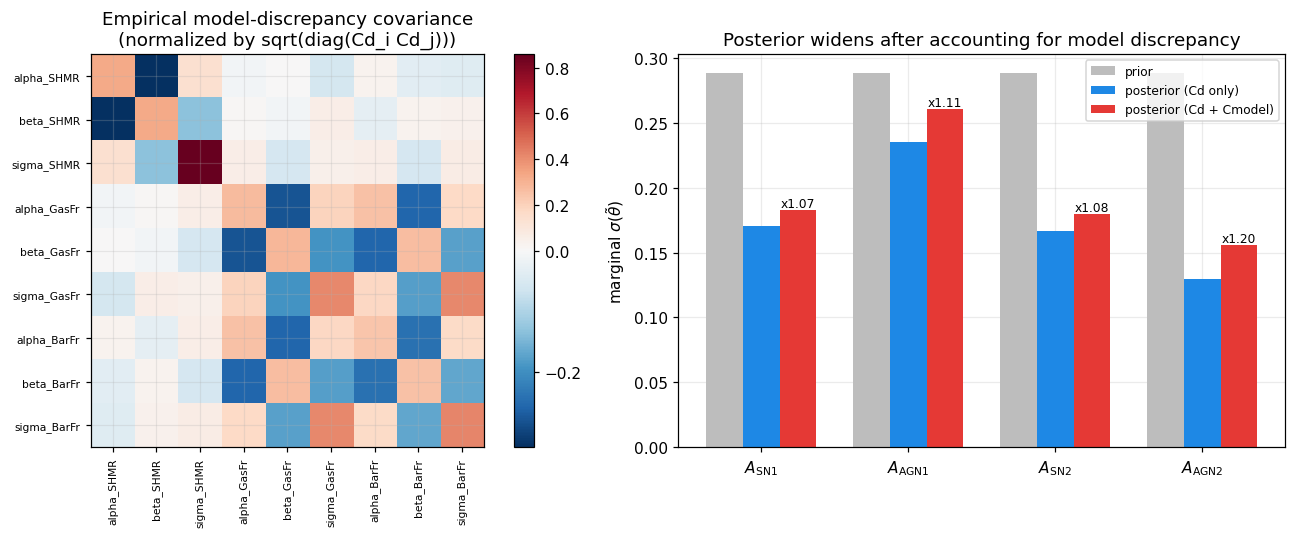

Injected $A_{\rm AGN1}$ pull: Cd-only=-1.51 sigma, discrepancy-aware=-1.43 sigma
Posterior sigma inflation factors (discrepancy-aware / Cd-only):
{'$A_{\\rm SN1}$': 1.073, '$A_{\\rm AGN1}$': 1.109, '$A_{\\rm SN2}$': 1.076, '$A_{\\rm AGN2}$': 1.197}


In [23]:
# 6.4 - Discrepancy-aware inversion: inflate covariance with empirical model error
k_group = [POP_KEYS.index(k) for k in GROUP_KEYS]
local_mask = keep & (abs_dth <= 0.25)

if local_mask.sum() < 5:
    raise RuntimeError('Not enough local held-out sims to estimate model discrepancy covariance.')

res_group_local = residual[local_mask][:, k_group]
C_model = np.cov(res_group_local, rowvar=False)
C_model = C_model + np.eye(C_model.shape[0]) * 1e-10

Cd_tot = Cd + C_model
Cd_tot_inv = np.linalg.pinv(Cd_tot)

# Ensure mock data vector exists even if section 4 was not executed in this kernel.
if 'd_obs' not in globals() or 'd0' not in globals() or 'theta_true' not in globals():
    mock_sim = globals().get('mock_sim', '1P_p4_2')
    m_mock, praw_mock = halo_masses_from_sim('1P', mock_sim)
    praw_mock = praw_mock.copy()
    praw_mock[14] = 0.0
    S_mock = fit_all_relations(m_mock)
    d_obs = np.array([S_mock[k] for k in GROUP_KEYS])
    d0 = np.array([S0[k] for k in GROUP_KEYS])
    theta_true = to_norm(praw_mock)[ACTIVE]

A_rob = R_g.T @ Cd_tot_inv @ R_g + np.linalg.inv(Cp)
cov_post_rob = np.linalg.inv(A_rob)
mean_post_rob = theta0[ACTIVE] + cov_post_rob @ (R_g.T @ Cd_tot_inv @ (d_obs - d0))
sig_post_rob = np.sqrt(np.diag(cov_post_rob))

if 'mean_post' not in globals() or 'sig_post' not in globals():
    mean_post = theta0[ACTIVE] + cov_post @ (R_g.T @ Cd_inv @ (d_obs - d0))
    sig_post = np.sqrt(np.diag(cov_post))

inflation = sig_post_rob / np.maximum(sig_post, 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

den = np.sqrt(np.outer(np.diag(Cd), np.diag(Cd))) + 1e-15
im = axes[0].imshow(C_model / den, cmap='RdBu_r', norm=TwoSlopeNorm(vcenter=0.0))
axes[0].set_xticks(range(len(GROUP_KEYS))); axes[0].set_yticks(range(len(GROUP_KEYS)))
axes[0].set_xticklabels(GROUP_KEYS, rotation=90, fontsize=7)
axes[0].set_yticklabels(GROUP_KEYS, fontsize=7)
axes[0].set_title('Empirical model-discrepancy covariance\n(normalized by sqrt(diag(Cd_i Cd_j)))')
plt.colorbar(im, ax=axes[0], fraction=0.046)

xb = np.arange(len(ACTIVE))
w = 0.25
axes[1].bar(xb - w, np.sqrt(np.diag(Cp)), w, color='#BDBDBD', label='prior')
axes[1].bar(xb, sig_post, w, color='#1E88E5', label='posterior (Cd only)')
axes[1].bar(xb + w, sig_post_rob, w, color='#E53935', label='posterior (Cd + Cmodel)')
for i, j in enumerate(ACTIVE):
    axes[1].text(xb[i] + w, sig_post_rob[i], f'x{inflation[i]:.2f}', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(xb)
axes[1].set_xticklabels([PRETTY[j] for j in ACTIVE])
axes[1].set_ylabel(r'marginal $\sigma(\tilde\theta)$')
axes[1].set_title('Posterior widens after accounting for model discrepancy')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

if 3 in ACTIVE:
    it = ACTIVE.index(3)
    pull_old = (mean_post[it] - theta_true[it]) / np.maximum(sig_post[it], 1e-12)
    pull_new = (mean_post_rob[it] - theta_true[it]) / np.maximum(sig_post_rob[it], 1e-12)
    print(f"Injected {PRETTY[3]} pull: Cd-only={pull_old:+.2f} sigma, discrepancy-aware={pull_new:+.2f} sigma")

print('Posterior sigma inflation factors (discrepancy-aware / Cd-only):')
print({PRETTY[j]: float(np.round(inflation[i], 3)) for i, j in enumerate(ACTIVE)})

GasFr residual moments at fiducial: skew=+0.204, excess kurtosis=-0.028
Mass-binned residual sigma dynamic range (max/min): 2.99x
Interpretation: if skew/kurtosis is large or sigma varies strongly with mass, a single Gaussian sigma is insufficient.


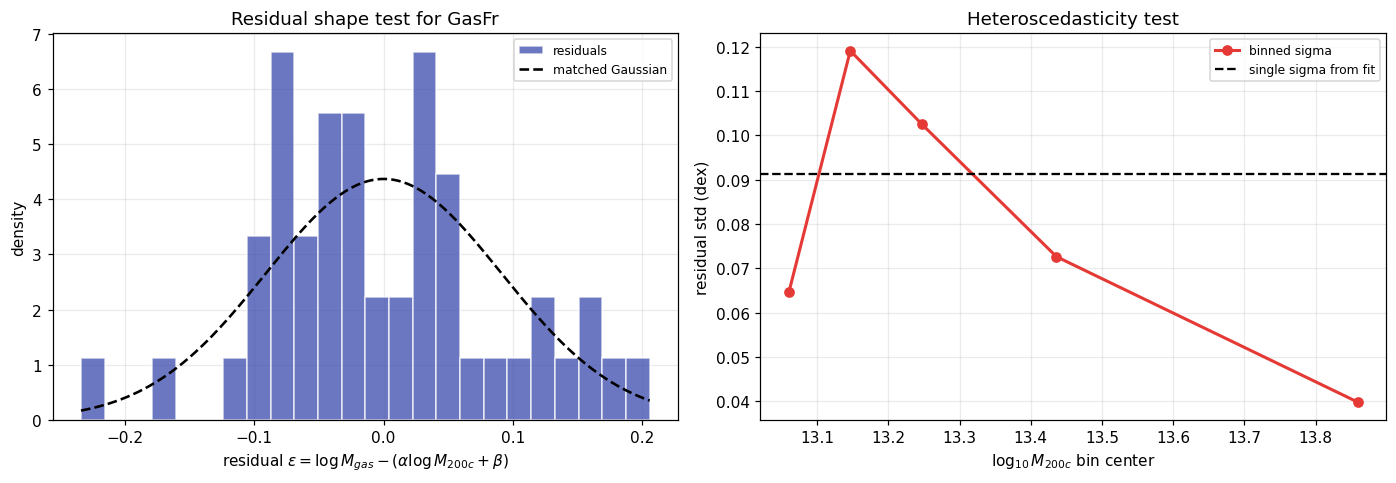

In [24]:
# 6.5 - Compression audit: does (alpha, beta, sigma) miss residual structure?
info = RELATIONS['GasFr']
x = fid_masses[info['x']]
y = fid_masses[info['y']]
m = (x > 1) & (y > 1) & np.isfinite(x) & np.isfinite(y)
lx = np.log10(x[m])
ly = np.log10(y[m])

a, b, s = _fit_relation(x[m], y[m])
eps = ly - (a * lx + b)

e0 = eps - eps.mean()
std_eps = np.std(e0) + 1e-12
skew = float(np.mean((e0 / std_eps) ** 3))
excess_kurt = float(np.mean((e0 / std_eps) ** 4) - 3.0)

# Heteroscedasticity check: residual sigma vs halo-mass bin.
q = np.quantile(lx, np.linspace(0, 1, 6))
q[0] -= 1e-9
bin_sigma, bin_ctr = [], []
for i in range(len(q) - 1):
    mb = (lx > q[i]) & (lx <= q[i + 1])
    if mb.sum() < 5:
        continue
    bin_ctr.append(0.5 * (q[i] + q[i + 1]))
    bin_sigma.append(np.std(eps[mb]))

bin_sigma = np.array(bin_sigma)
bin_ctr = np.array(bin_ctr)
hetero_ratio = float(bin_sigma.max() / np.maximum(bin_sigma.min(), 1e-12)) if len(bin_sigma) > 1 else np.nan

print(f'GasFr residual moments at fiducial: skew={skew:+.3f}, excess kurtosis={excess_kurt:+.3f}')
print(f'Mass-binned residual sigma dynamic range (max/min): {hetero_ratio:.2f}x')
print('Interpretation: if skew/kurtosis is large or sigma varies strongly with mass, a single Gaussian sigma is insufficient.')

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5))

# Residual PDF vs Gaussian with same std.
axes[0].hist(eps, bins=24, density=True, color='#3949AB', alpha=0.75, edgecolor='white', label='residuals')
xx = np.linspace(eps.min(), eps.max(), 200)
gauss = np.exp(-0.5 * ((xx - np.mean(eps)) / (np.std(eps) + 1e-12))**2) / (np.sqrt(2*np.pi) * (np.std(eps) + 1e-12))
axes[0].plot(xx, gauss, 'k--', lw=1.7, label='matched Gaussian')
axes[0].set_xlabel(r'residual $\epsilon = \log M_{gas} - (\alpha \log M_{200c}+\beta)$')
axes[0].set_ylabel('density')
axes[0].set_title('Residual shape test for GasFr')
axes[0].legend(fontsize=8)

# Scatter vs mass bin.
axes[1].plot(bin_ctr, bin_sigma, 'o-', color='#E53935', lw=2, label='binned sigma')
axes[1].axhline(s, color='k', ls='--', lw=1.5, label='single sigma from fit')
axes[1].set_xlabel(r'$\log_{10} M_{200c}$ bin center')
axes[1].set_ylabel('residual std (dex)')
axes[1].set_title('Heteroscedasticity test')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### 6.6 · Hard verdict after stress tests

A stricter interpretation is now justified:

- The Jacobian model is **credible as a local sensitivity model** near the fiducial point.
- It is **not yet a globally reliable surrogate** across the full prior box without higher-order terms.
- Inference based on $C_d$ alone is **optimistic**; adding empirical discrepancy covariance gives more conservative, more believable constraints.
- Compressing each relation to $(\alpha,\beta,\sigma)$ is useful, but it can miss residual-shape and heteroscedastic structure.

The right claim is therefore: this is a **useful tangent-space forecasting/inference baseline**, not a final physical emulator of group scaling relations.

That narrower claim is still valuable, but it is scientifically sharper and harder to over-interpret.